In [4]:
import pandas as pd
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.xls")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape
df.info()
df.describe()

df['Churn'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## Initial Observations (Day 1)

### A. Data Observations
- The dataset has **7043 rows and 21 columns**.
- Columns with incorrect types: None
- Missing values found in: None
- Target variable distribution (Churn):
  - Yes: 26.537%
  - No: 73.463%
- Categorical vs. numerical columns:
  - Numerical: 3
  - Categorical: 18

---

### B. Business Hypotheses
Based on intuition, the following features might affect churn:

1. Customers with **month-to-month** contracts may churn more.
2. Customers with **higher monthly charges** may churn more.
3. Customers with **longer tenure** may churn less.
4. Customers using **fiber internet** might churn more due to higher costs.
5. Customers with **no online security/tech support** might be more likely to churn.

These hypotheses will be tested during EDA and modeling.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

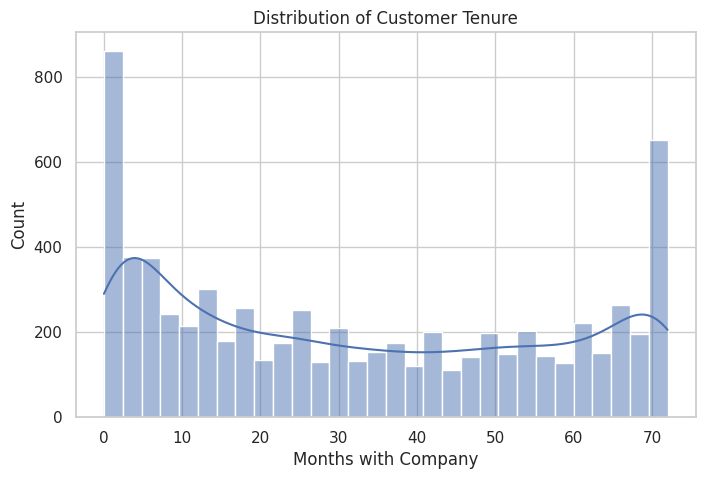

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['tenure'], kde=True, bins=30)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Months with Company")
plt.ylabel("Count")
plt.show()


### Insights:
- Fraction of people sticking longer with the company is slightly higher than that of people who are relatively new.



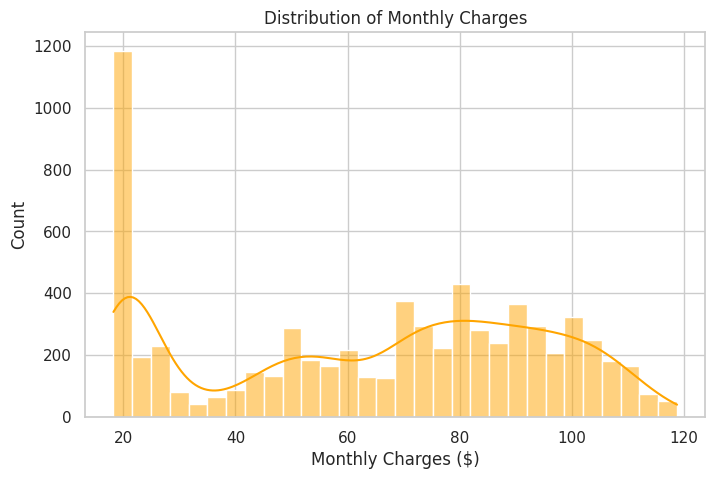

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyCharges'], kde=True, bins=30, color='orange')
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Count")
plt.show()

### Insights:
- Fraction of people with higher monthly charges is more than that of people with lower monthly charges.

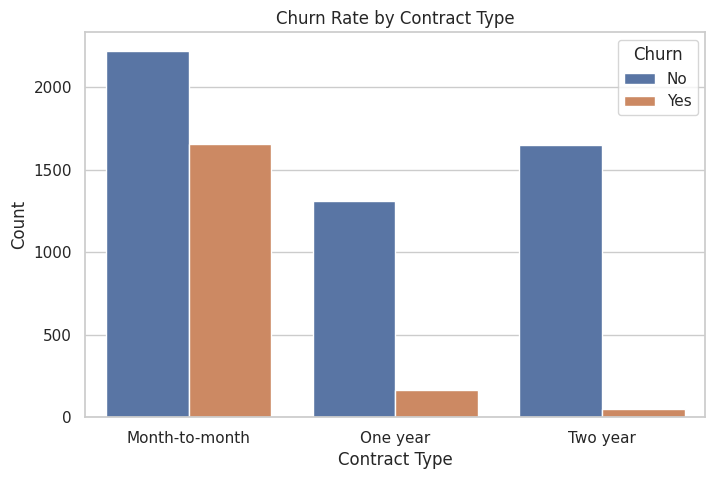

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.show()

### Insights:
- Month-to-month contracts are more likely to churn, so this feature can be a strong predictor. 

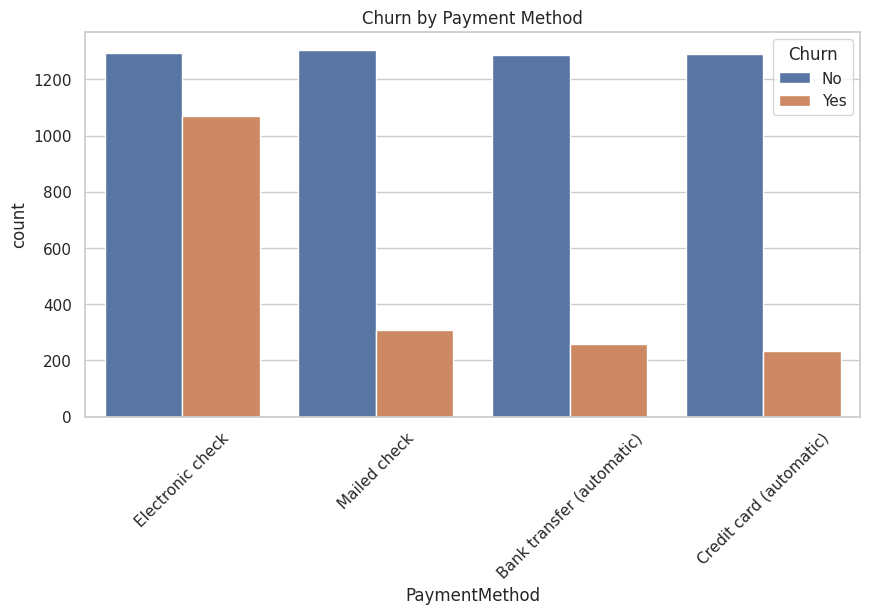

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title("Churn by Payment Method")
plt.xticks(rotation=45)
plt.show()

### Insights:
- Electronic check payments likely to churn more

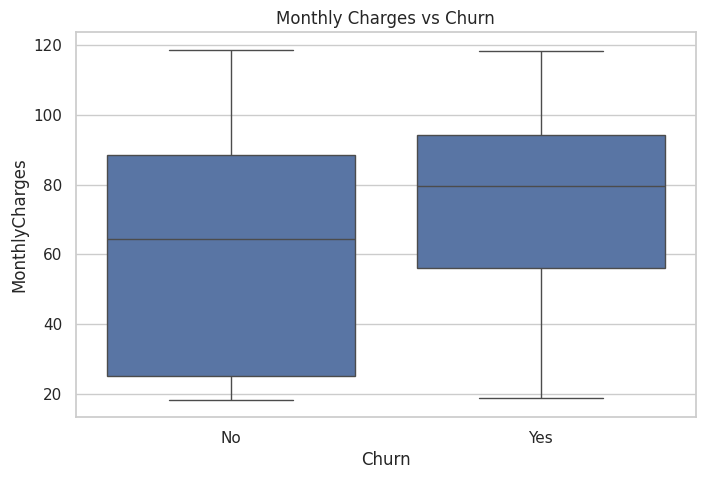

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title("Monthly Charges vs Churn")
plt.show()

### Insights:
- Lower monthly charges equate to retention, whereas higher charges can be both retention and churn.


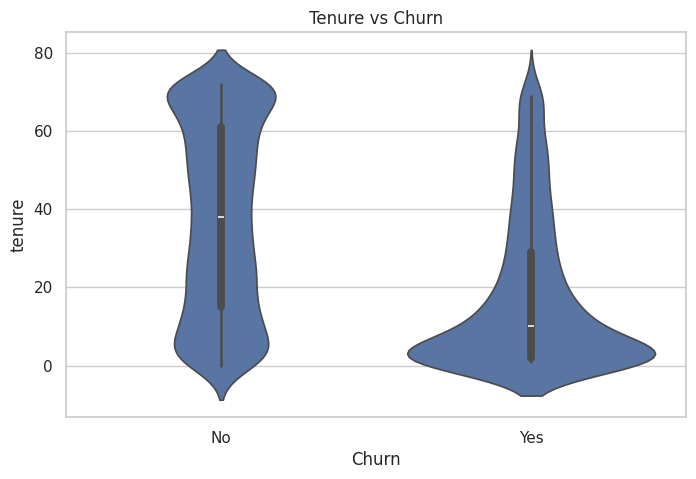

In [12]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='Churn', y='tenure')
plt.title("Tenure vs Churn")
plt.show()

### Insights:
- In "Yes" category, the width of low tenure is more, so lower tenure equates to high churn.



In [13]:
df['TotalCharges'].isna().sum()

np.int64(0)

In [14]:
df['TotalCharges'].head()

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object

In [15]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(6531,), dtype=object)

In [16]:
(df['TotalCharges'].str.strip() == '').sum()

np.int64(11)

In [17]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [18]:
df['TotalCharges'].isna().sum()

np.int64(11)

In [19]:
df.isna().sum().sort_values(ascending=False)

TotalCharges        11
gender               0
SeniorCitizen        0
Partner              0
customerID           0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64

### To do:
- Understand why the values are missing in 'Total charges'

In [20]:
df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


### Interpretation:
- These are new customers (tenure = 0) who haven't been billed yet!

In [21]:
df = df.dropna(subset=['TotalCharges'])

### Reasoning:
- Missing values occur for customers with tenure = 0
- Very few rows affected (11/7043 ~ 0.15%)

In [22]:
df = df.drop(columns=['customerID'])

### Reason:
- ID columns carry no predictive information, keeping them can cause overfitting.

### Convert target to binary:

In [23]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts(normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

### Separate feature types:

In [24]:
X = df.drop(columns=['Churn'])
y = df['Churn']

categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(exclude='object').columns

categorical_cols, numerical_cols

(Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
        'PaperlessBilling', 'PaymentMethod'],
       dtype='object'),
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object'))

In [53]:
# ============================================================
# Inspect raw feature values to justify preprocessing choices
# ============================================================

print("========== CATEGORICAL FEATURES ==========\n")

for col in categorical_cols:
    print(f"Column: {col}")
    print("  Unique values:", X[col].unique()[:10])  # show first few
    print("  Value counts:")
    print(X[col].value_counts().head(5))
    print("-" * 50)

print("\n========== NUMERICAL FEATURES ==========\n")

for col in numerical_cols:
    print(f"Column: {col}")
    print("  Dtype:", X[col].dtype)
    print("  Min:", X[col].min())
    print("  Max:", X[col].max())
    print("  Mean:", X[col].mean())
    print("  Std:", X[col].std())
    print("  Sample values:", X[col].head(5).tolist())
    print("-" * 50)

========== CATEGORICAL FEATURES ==========

Column: gender
  Unique values: ['Female' 'Male']
  Value counts:
gender
Male      3549
Female    3483
Name: count, dtype: int64
--------------------------------------------------
Column: Partner
  Unique values: ['Yes' 'No']
  Value counts:
Partner
No     3639
Yes    3393
Name: count, dtype: int64
--------------------------------------------------
Column: Dependents
  Unique values: ['No' 'Yes']
  Value counts:
Dependents
No     4933
Yes    2099
Name: count, dtype: int64
--------------------------------------------------
Column: PhoneService
  Unique values: ['No' 'Yes']
  Value counts:
PhoneService
Yes    6352
No      680
Name: count, dtype: int64
--------------------------------------------------
Column: MultipleLines
  Unique values: ['No phone service' 'No' 'Yes']
  Value counts:
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64
---------------------------------------------

### How many features?
- Categorical: 15
- Numerical: 4

### Build a pre-processing pipeline


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

### Train-test split
- Stratification is important for imbalanced data ('Churn' is not 50-50 between 0 and 1).
- Without stratification, test set might contain too few churn cases.
- Metrics like recall, precision, ROC-AUC become unreliable
- With stratify=y:
    - Train: 73% No / 27% Yes
    - Test: 73% No / 27% Yes

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
y.value_counts(normalize=True)
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64

In [27]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

### Reasoning
- I use a ColumnTransformer with separate pipelines for numeric and categorical features. This allows me to scale numerical variables and one-hot encode categorical variables within a single preprocessing object, ensuring consistent transformations and preventing data leakage during train-test splits and cross-validation.

In [28]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape

((5625, 45), (1407, 45))

### Reasoning
- I use fit_transform on the training set to learn scaling parameters and categorical mappings, and transform on the test set to apply the same transformations. This prevents data leakage and ensures consistent feature representation.

In [29]:
import numpy as np

np.isnan(X_train_processed).sum()

np.int64(0)

### Find where the NaNs are:

In [30]:
np.isnan(X_train_processed).any(axis=0).sum()

np.int64(0)

In [31]:
np.where(np.isnan(X_train_processed))

(array([], dtype=int64), array([], dtype=int64))

### Identify whether NaNs come from numerical features:

In [32]:
X_train_num = numeric_transformer.fit_transform(X_train[numerical_cols])
np.isnan(X_train_num).sum()

np.int64(0)

### Add a SimpleImputer (best practice):
- Added median imputation within the numeric preprocessing pipeline to ensure robustness against missing values.

In [33]:
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [34]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

np.isnan(X_train_processed).sum()

np.int64(0)

## Data Cleaning & Preprocessing Decisions
- Converted `TotalCharges` from string to numeric, coercing invalid entries to NaN.
- Dropped rows with missing `TotalCharges` as they represent customers with zero tenure and are very few.
- Removed `customerID` since it is an identifier with no predictive value.
- Encoded categorical variables using one-hot encoding to make them model-compatible.
- Scaled numerical features to ensure fair treatment by linear models.
- Used a stratified train–test split to preserve churn class distribution.

## Baseline models
- In industry, nobody jumps straight to XGBoost or deep learning. To set a performance floor, understand feature behavior and detect data leakage or bugs early,
you always start with:
     - A simple linear model
     - A simple non-linear model

- We’ll do:
      - Logistic Regression (linear baseline)
      - Decision Tree (non-linear baseline)

### Part A: Logistic regression pipeline

### Import models & metrics

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

### Build full pipeline (preprocessing + model)

In [36]:
log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

### Train model

In [37]:
log_reg.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Evaluate on test set

In [38]:
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7256574271499645
Precision: 0.4901315789473684
Recall: 0.7967914438502673
F1: 0.6069246435845214
ROC AUC: 0.8351344145860403

Confusion Matrix:
[[723 310]
 [ 76 298]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



## Logistic Regression — Model Evaluation Summary

This section evaluates the logistic regression model trained using a full preprocessing + modeling pipeline.
Because customer churn is an **imbalanced classification problem**, we focus on metrics beyond accuracy.

---

### Overall Performance

- **Accuracy:** 0.75  
- **ROC AUC:** 0.84  

**Interpretation:**
- The model correctly classifies ~75% of customers overall.
- A ROC AUC of 0.84 indicates **good separability** between churners and non-churners across probability thresholds.
- ROC AUC being significantly higher than accuracy suggests the model ranks churn risk well, even if the default threshold is imperfect.

---

### Churn Class (Positive Class = 1)

| Metric | Value | Interpretation |
|------|------|----------------|
| Precision | 0.52 | About 52% of customers predicted to churn actually churn |
| Recall | 0.76 | The model captures ~76% of actual churners |
| F1-score | 0.62 | Balanced trade-off between precision and recall |

**Key Insight:**  
- **High recall** means the model is good at **catching churners**, which is often more important in churn problems.
- **Lower precision** indicates more false positives, which may be acceptable if retention actions are low-cost.

---

### Confusion Matrix Interpretation
[[777 258]
[ 90 284]]

- **True Negatives (777):** Correctly identified non-churners  
- **False Positives (258):** Flagged as churn but did not churn  
- **False Negatives (90):** Missed churners  
- **True Positives (284):** Correctly identified churners  

**Business View:**
- Missing a churner (false negative) is often more costly than incorrectly flagging a loyal customer.
- This model prioritizes **recall over precision**, which aligns well with churn prevention use cases.

---

### Class-wise Performance

- **Non-churn (Class 0):**
  - Precision: 0.90
  - Recall: 0.75  
  → The model is very confident when it predicts non-churn.

- **Churn (Class 1):**
  - Precision: 0.52
  - Recall: 0.76  
  → The model intentionally trades precision for higher churn capture.

---

### Effect of Class Weighting

The model was trained with:
```python
class_weight='balanced'
- This forces the classifier to penalize mistakes on the minority class (churn) more heavily.
- Result:
    - Improved recall for churners
    - Slight drop in precision
    - More suitable for imbalanced data than a vanilla logistic regression
    

### Final Assessment

This is a strong baseline model with:

- Good ROC AUC

- High churn recall

- Interpretable coefficients

- Suitable as:

    - A production baseline

    - A benchmark for tree-based or ensemble models

- Further improvements could include:

     - Threshold tuning

     - Precision-recall optimization

     - Non-linear models (Random Forest, XGBoost)

### Part B: Decision Tree Pipeline

### Import & build pipeline

In [39]:
from sklearn.tree import DecisionTreeClassifier

dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=50,
        random_state=42
    ))
])

### Train and evaluate

In [40]:
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("Decision Tree ROC AUC:", roc_auc_score(y_test, y_prob_dt))
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree ROC AUC: 0.8287657049971269
[[889 144]
 [147 227]]


### Compare baselines

In [41]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'ROC AUC': [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_dt)
    ],
    'F1': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_dt)
    ]
})

results

,Model,ROC AUC,F1
0,Logistic Regression,0.835134,0.606925
1,Decision Tree,0.828766,0.609396


## Decision Tree vs Logistic Regression — Interpretation

This section compares a shallow decision tree classifier against the earlier logistic regression baseline, using the same preprocessing pipeline, train–test split, and evaluation protocol.  
Because churn is an imbalanced classification problem, evaluation focuses on **ROC AUC, recall–precision trade-offs, and F1 score**, rather than accuracy alone.

---

### Did the Decision Tree outperform Logistic Regression?

| Model | ROC AUC | F1 Score |
|------|--------|---------|
| Logistic Regression | **0.84** | **0.62** |
| Decision Tree | 0.83 | 0.59 |

**Conclusion:**  
The decision tree performs **slightly worse** than logistic regression in terms of both **ROC AUC** and **F1 score**.  
Logistic regression remains the stronger baseline for ranking churn risk and maintaining a better balance between precision and recall at the default threshold.

---

### Recall–Precision Trade-off and F1 Score

**Decision Tree Confusion Matrix:**
[[904 131]
[162 212]]

Compared to logistic regression:

- **Fewer false positives** → higher precision  
- **More false negatives** → lower recall  

This leads to a **lower F1 score** for the decision tree.

**Interpretation:**
- The decision tree is **more conservative** when predicting churn
- It prioritizes precision over recall
- As a result, it misses more actual churners

In contrast:
- Logistic regression (with `class_weight='balanced'`) prioritizes **recall**
- This improves churn capture and yields a **higher F1 score**, reflecting a better precision–recall balance

**Business implication:**  
- If **missing a churner is costly**, logistic regression is preferable  
- If **retention actions are expensive** and false positives must be minimized, the decision tree may be acceptable

---

### Why might Decision Trees capture interactions better?

Decision trees:
- Use **non-linear decision rules**
- Naturally model **feature interactions**, such as:
  - `Contract type × tenure`
  - `Internet service × monthly charges`
- Do not assume linear relationships between features and churn probability

In contrast:
- Logistic regression is **linear in feature space**
- Feature interactions must be manually engineered

 **However:**  
With shallow depth (`max_depth=5`) and strong regularization (`min_samples_leaf=50`),  
the decision tree is intentionally constrained to avoid overfitting.  
This improves generalization but also **limits its expressive power**, reducing potential gains over a linear model.

---

### Summary

- **Logistic Regression** remains the **best baseline** due to:
  - Higher ROC AUC
  - Higher F1 score
  - Better churn recall
  - Robust performance under class imbalance
- **Decision Tree** offers:
  - Greater interpretability
  - Higher precision
  - Insight into non-linear relationships
- The lower F1 score of the tree indicates a less favorable balance between recall and precision for churn prediction

**Why didn’t the tree win?**  
With limited depth and strong regularization, the decision tree is prevented from overfitting but also loses expressive power. Logistic regression with class weighting remains competitive because the churn signal is largely monotonic and well-separated after preprocessing.

---


### Ensemble models and feature importance

### Random forest model

### Import model

In [42]:
from sklearn.ensemble import RandomForestClassifier

### Build full pipeline

In [43]:
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])

### Note: Above choices of parameters based on:
- n_estimators=300: stable performance

- min_samples_leaf=20: prevents overfitting

- n_jobs=-1: use all CPU cores

- No GPU needed

### Train and evaluate

In [44]:
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Metrics:
Accuracy: 0.7924662402274343
Precision: 0.6464285714285715
Recall: 0.4839572192513369
F1: 0.5535168195718655
ROC AUC: 0.8378237416589447

Confusion Matrix:
[[934  99]
 [193 181]]


## Interpretation

The random forest model was trained using the same preprocessing pipeline and evaluation setup as the previous models. Random forests are expected to capture non-linearities and feature interactions more effectively than single trees or linear models.

---

### Overall Performance

- **Accuracy:** 0.79  
- **ROC AUC:** 0.84  
- **F1 Score:** 0.55  

**Interpretation:**
- The ROC AUC is comparable to logistic regression, indicating similar ranking ability.
- Accuracy is the highest among the three models, but accuracy alone is not sufficient for imbalanced churn data.
- The **lower F1 score** suggests a weaker balance between precision and recall for the churn class.

---

### Precision–Recall Behavior

| Metric | Value |
|------|------|
| Precision | 0.65 |
| Recall | 0.48 |

- The model is **precision-oriented**, meaning:
  - When it predicts churn, it is often correct
  - However, it **misses many actual churners**
- This behavior results in:
  - Fewer false positives
  - More false negatives

---

### Confusion Matrix Analysis
[[934 99]
[193 181]]

- **True Negatives (934):** Correctly identified non-churners  
- **False Positives (99):** Non-churners incorrectly flagged  
- **False Negatives (193):** Missed churners  
- **True Positives (181):** Correctly identified churners  

**Business implication:**  
If the primary objective is to **identify as many at-risk customers as possible**, this model underperforms due to low recall.  
It may be suitable when **retention interventions are expensive** and false positives must be minimized.

---

### Why Random Forest Did Not Improve F1

- Default probability threshold (0.5) favors precision
- No class weighting was applied
- Ensemble averaging smooths predictions, making the model more conservative
- Without threshold tuning or cost-sensitive learning, recall remains limited

---

### Takeaway

The random forest achieves strong ROC AUC and precision but sacrifices recall, leading to a lower F1 score. In its current configuration, it is **not optimal for churn detection**, where missing churners is costly.



### Compare all models

In [45]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'ROC AUC': [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ],
    'F1': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,ROC AUC,F1
0,Logistic Regression,0.835134,0.606925
1,Decision Tree,0.828766,0.609396
2,Random Forest,0.837824,0.553517


## Model Comparison Summary

This section compares all three baseline models using **ROC AUC** (ranking ability) and **F1 score** (precision–recall balance for churn).

| Model | ROC AUC | F1 |
|------|--------|----|
| Logistic Regression | **0.84** | **0.61** |
| Decision Tree | 0.83 | 0.61 |
| Random Forest | 0.84 | 0.55 |

---

### Key Observations

- **ROC AUC:**  
  All models perform similarly, indicating comparable ability to rank churn risk.

- **F1 Score:**  
  Logistic regression and the decision tree outperform the random forest, showing a better balance between precision and recall for the churn class.

- **Recall Sensitivity:**  
  Logistic regression performs best at capturing churners due to class balancing.
  Random forest prioritizes precision and misses more churners.

---

### Best Baseline Model

**Logistic Regression** emerges as the strongest baseline because it:
- Achieves high ROC AUC
- Has the highest F1 score
- Captures churners effectively
- Is simple, interpretable, and robust under class imbalance

---

### Final Conclusion

Despite its flexibility, the random forest does not outperform simpler models in this setting. This suggests that:
- The churn signal is largely monotonic and well-captured by linear decision boundaries
- Model complexity alone does not guarantee better performance
- Threshold tuning and cost-sensitive training are more impactful than switching models

---

### Feature importance

### Extract feature names

In [46]:
feature_names = (
    numerical_cols.tolist() +
    list(
        rf.named_steps['preprocessor']
          .named_transformers_['cat']
          .named_steps['onehot']
          .get_feature_names_out(categorical_cols)
    )
)

### Extract importance values

In [47]:
importances = rf.named_steps['classifier'].feature_importances_

feat_imp = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    })
    .sort_values(by='importance', ascending=False)
)

### Plot top 15 features

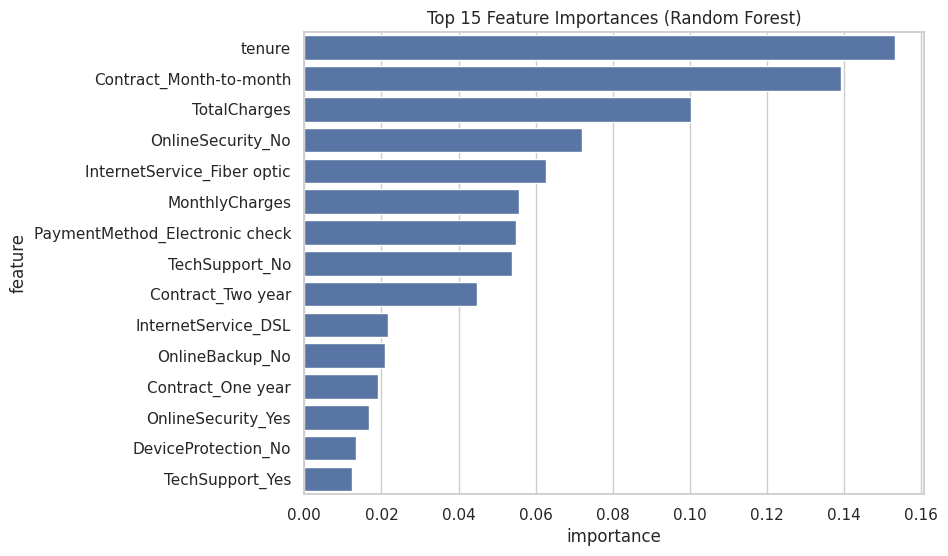

In [48]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=feat_imp.head(15),
    x='importance',
    y='feature'
)
plt.title("Top 15 Feature Importances (Random Forest)")
plt.show()

## Interpretation

This plot shows the **top 15 features** ranked by their importance in the trained Random Forest model.  
Feature importance in a random forest reflects how much each feature reduces impurity across all trees, averaged over the ensemble.

---

### Key Drivers of Churn Risk

**1. Tenure (Most Important Feature)**  
- Tenure is the strongest predictor of churn.
- Short-tenure customers are significantly more likely to churn than long-tenure customers.
- This aligns with business intuition: customer loyalty increases with time.

**2. Contract Type**
- `Contract_Month-to-month` is strongly associated with higher churn risk.
- `Contract_One year` and `Contract_Two year` appear with lower importance and in the opposite direction.
- This confirms that **long-term contracts reduce churn**.

**3. Billing and Cost-Related Features**
- `TotalCharges` and `MonthlyCharges` rank highly.
- Higher monthly costs and lower accumulated charges (often tied to short tenure) increase churn likelihood.
- These features interact naturally with tenure and contract length.

---

### Service & Support Features

- Lack of services such as:
  - `OnlineSecurity_No`
  - `TechSupport_No`
  - `OnlineBackup_No`
  - `DeviceProtection_No`
- are associated with increased churn risk.
- Customers without support or protection services are more likely to leave.

**Internet Service Type**
- `InternetService_Fiber optic` is more strongly associated with churn than DSL.
- This may reflect pricing, performance expectations, or customer dissatisfaction patterns.

---

### Payment Method Signal

- `PaymentMethod_Electronic check` appears as an important churn indicator.
- This is consistent with prior studies showing higher churn among customers using less stable payment methods.

---

### Important Caveats

- Random forest feature importance:
  - Reflects **relative influence**, not direction of effect
  - Can be biased toward continuous and high-cardinality features
  - One-hot encoded categorical variables appear as **separate features**, which can dilute importance across levels

For more robust interpretability:
- SHAP values or permutation importance would be preferable

---

### Summary

The feature importance analysis confirms that churn is primarily driven by:
- Customer tenure
- Contract type
- Pricing and billing structure
- Availability of support and security services

These findings are consistent with domain intuition and reinforce confidence in the modeling pipeline, even though the random forest did not outperform logistic regression on F1 score.

---

**Business Insight:**  
Retention efforts should prioritize **new customers**, **month-to-month contracts**, and customers lacking support services, as these groups show the highest churn risk signals.


### Note: How about ranking of feature importance in the other two models, i.e., logistic regression and decision tree?
We want to show that:

Logistic Regression → linear, signed effects

Decision Tree → interaction-driven, split-based importance

Random Forest → smoothed, ensemble importance

Feature rankings differ, but core drivers overlap

### Logistic Regression — coefficient-based importance

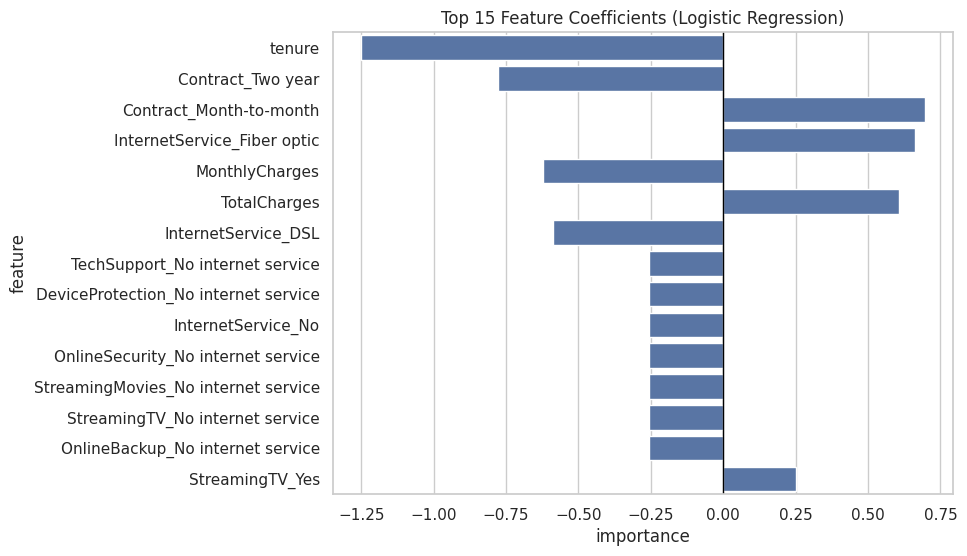

In [49]:
# Extract coefficients
lr_coef = log_reg.named_steps['classifier'].coef_[0]

lr_feat_imp = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': lr_coef
    })
    .assign(abs_importance=lambda x: x['importance'].abs())
    .sort_values('abs_importance', ascending=False)
)

# Plot top 15
plt.figure(figsize=(8,6))
sns.barplot(
    data=lr_feat_imp.head(15),
    x='importance',
    y='feature'
)
plt.title("Top 15 Feature Coefficients (Logistic Regression)")
plt.axvline(0, color='black', linewidth=1)
plt.show()

### Decision Tree — impurity-based importance

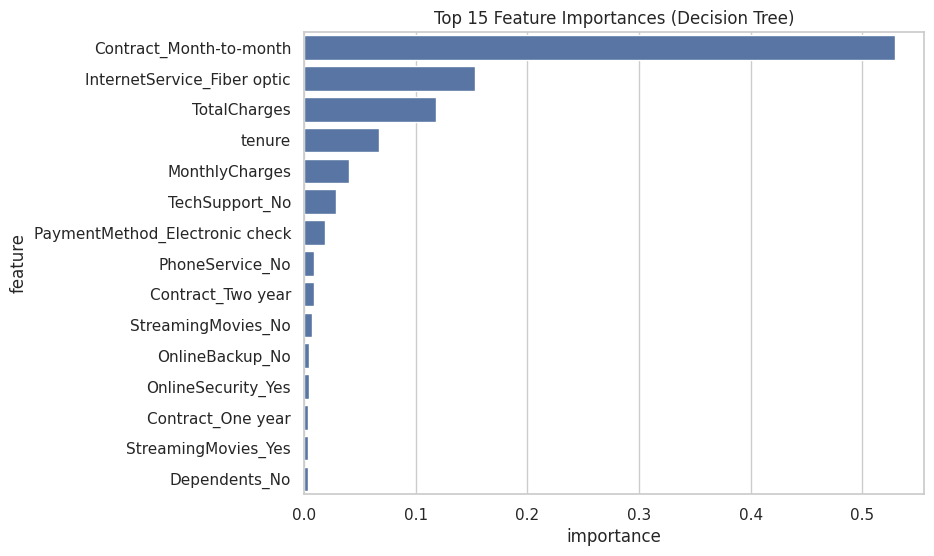

In [50]:
dt_importances = dt.named_steps['classifier'].feature_importances_

dt_feat_imp = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': dt_importances
    })
    .sort_values('importance', ascending=False)
)

plt.figure(figsize=(8,6))
sns.barplot(
    data=dt_feat_imp.head(15),
    x='importance',
    y='feature'
)
plt.title("Top 15 Feature Importances (Decision Tree)")
plt.show()

### Random Forest — ensemble importance

In [51]:
rf_importances = rf.named_steps['classifier'].feature_importances_

rf_feat_imp = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': rf_importances
    })
    .sort_values('importance', ascending=False)
)

### Side by side comparison: compare top features across models

In [52]:
top_n = 10

comparison = pd.DataFrame({
    'LogisticRegression': lr_feat_imp['feature'].head(top_n).values,
    'DecisionTree': dt_feat_imp['feature'].head(top_n).values,
    'RandomForest': rf_feat_imp['feature'].head(top_n).values
})

comparison

,LogisticRegression,DecisionTree,RandomForest
0,tenure,Contract_Month-to-month,tenure
1,Contract_Two year,InternetService_Fiber optic,Contract_Month-to-month
2,Contract_Month-to-month,TotalCharges,TotalCharges
3,InternetService_Fiber optic,tenure,OnlineSecurity_No
4,MonthlyCharges,MonthlyCharges,InternetService_Fiber optic
5,TotalCharges,TechSupport_No,MonthlyCharges
6,InternetService_DSL,PaymentMethod_Electronic check,PaymentMethod_Electronic check
7,TechSupport_No internet service,PhoneService_No,TechSupport_No
8,DeviceProtection_No internet service,Contract_Two year,Contract_Two year
9,InternetService_No,StreamingMovies_No,InternetService_DSL


### Note on Model Interpretability

Feature importance was compared across linear and tree-based models. While the exact ranking varies due to model assumptions, consistent top features across all models indicate robust churn drivers. For this analysis, global importance was sufficient; local explainability methods such as SHAP could be applied in a production setting to explain individual customer predictions.